In [1]:
from collections.abc import Mapping
from pathlib import Path
from typing import Any

import numpy as np
from dataeval.data import Indices, Limit, Shuffle, View
from datamaite import load_ic
from maite_datasets.image_classification import MilitaryVehicles
from numpy.typing import NDArray

data_root = Path("./data")
MilitaryVehicles(root=data_root, image_set="base", download=True)
MilitaryVehicles(root=data_root, image_set="train", as_datamaite=True)

vehicles_raw = load_ic(data_root / "militaryvehicles_datamaite_train" / "train", dataset_format="huggingface_vision")

# The loader groups samples by class folder, so raw index order is alphabetical by class.
# Shuffle imposes a seeded sequence that this tutorial treats as collection order.
# The degradation wrapper and chunked view in Phase 1 rely on this ordering.
#
# `View` is the same machinery a `ViewConfig` drives from the pipeline config, used
# directly because the degradation wrapper needs the ordered dataset in hand before the
# workflow ever sees it. `resolve_indices()` hands back the source indices in selection
# order, which is how the incoming slice below is cut without re-deriving the shuffle.
vehicles = View(vehicles_raw, [Shuffle(seed=42), Limit(4000)])
_order = vehicles.resolve_indices()

index2label = vehicles_raw.metadata.get("index2label", {})
DEGRADED = {4, 10, 19}
print(f"Loaded {len(vehicles)} images across {len(index2label)} classes")
print(f"Degrading: {[index2label[c] for c in sorted(DEGRADED)]}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 4000 images across 24 classes
Degrading: ['BMP-1', 'BTR-80', 'T-72']


In [2]:
from PIL import Image, ImageFilter


class DegradedDataset:
    """Wraps a MAITE dataset and applies progressive Gaussian blur to selected classes.

    Parameters
    ----------
    dataset
        A MAITE-compatible dataset returning (image, target, metadata) tuples,
        with images as CHW uint8 arrays (datamaite's native image format).
    degraded_classes
        Set of class labels to apply blur to.
    max_blur_radius
        Maximum blur radius applied to the last sample.
    """

    def __init__(
        self,
        dataset: Any,
        degraded_classes: set[int],
        max_blur_radius: float = 3.0,
    ) -> None:
        self._dataset = dataset
        self._degraded_classes = degraded_classes
        self.max_blur_radius: float = max_blur_radius

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        t = np.asarray(target)
        label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)

        if label in self._degraded_classes:
            # Blur increases linearly with index to simulate progressive degradation
            progress = index / max(len(self) - 1, 1)
            radius = self.max_blur_radius * progress

            if radius > 0.1:  # skip negligible blur
                chw = np.asarray(image)
                hwc = np.transpose(chw, (1, 2, 0))  # CHW -> HWC
                img_pil = Image.fromarray(hwc, mode="RGB").filter(ImageFilter.GaussianBlur(radius=radius))
                image = np.transpose(np.array(img_pil, dtype=chw.dtype), (2, 0, 1))  # back to CHW

        return image, target, metadata

In [3]:

# Wrap the incoming slice with degradation for classes 1, 4, 7
incoming_maite = View(vehicles_raw, [Indices(_order[2000:4000])])
incoming_dataset = DegradedDataset(
    incoming_maite,
    degraded_classes=DEGRADED,
    max_blur_radius=6.0,
)

print(f"Reference: {len(vehicles)} total frames (will select first 2000)")
print(f"Incoming:  {len(incoming_dataset)} frames ({len(DEGRADED)} classes progressively blurred)")

Reference: 4000 total frames (will select first 2000)
Incoming:  2000 frames (3 classes progressively blurred)


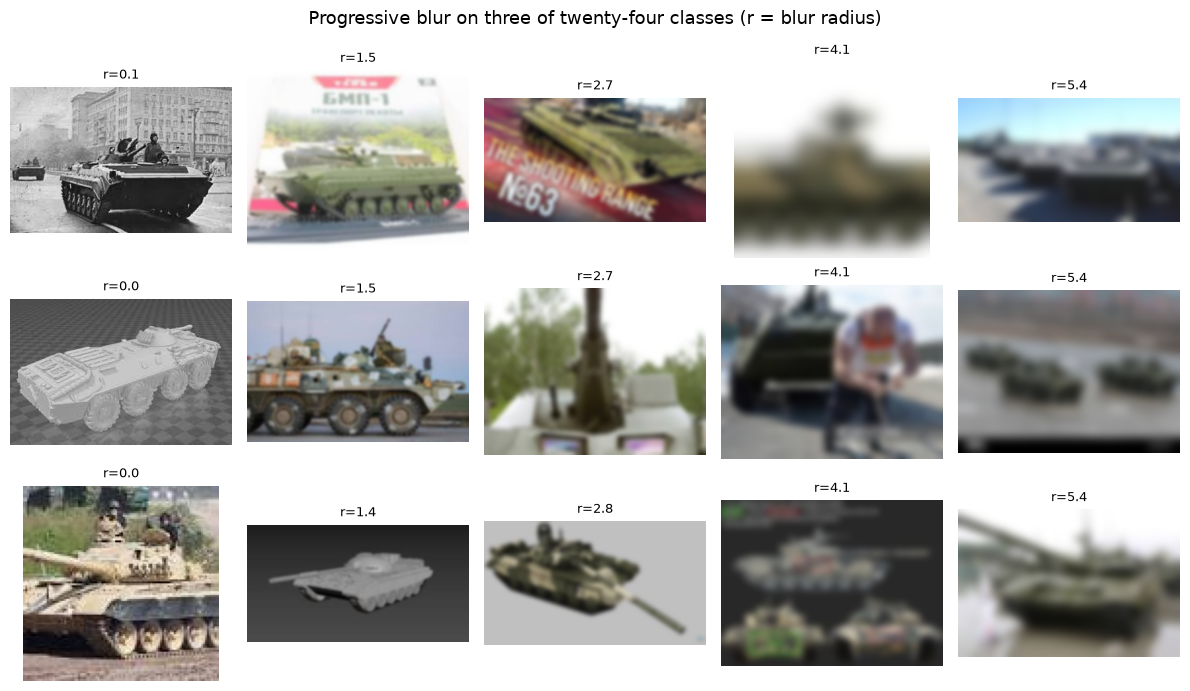

In [4]:
import matplotlib.pyplot as plt

degraded_classes = sorted(DEGRADED)
positions = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(len(degraded_classes), len(positions), figsize=(12, 7))

for row, cls in enumerate(degraded_classes):
    for col, frac in enumerate(positions):
        start = int(frac * len(incoming_dataset) * 0.9)
        for i in range(start, len(incoming_dataset)):
            img, target, _ = incoming_dataset[i]
            t = np.asarray(target)
            label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)
            if label == cls:
                img_arr = np.transpose(np.asarray(img), (1, 2, 0))  # CHW -> HWC
                axes[row, col].imshow(img_arr)
                radius = incoming_dataset.max_blur_radius * (i / max(len(incoming_dataset) - 1, 1))
                axes[row, col].set_title(f"r={radius:.1f}", fontsize=9)
                break
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(index2label[cls], fontsize=11, rotation=0, labelpad=60)

fig.suptitle("Progressive blur on three of twenty-four classes (r = blur radius)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
import torch
import torchvision

# Cache ResNet-18 weights locally for TorchExtractorConfig
model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "resnet18.pt"
if not model_path.exists():
    torch.save(torchvision.models.resnet18(weights="IMAGENET1K_V1").eval(), model_path)
print(f"Extractor model: {model_path}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

 32%|███▏      | 14.2M/44.7M [00:00<00:00, 149MB/s]

 70%|██████▉   | 31.1M/44.7M [00:00<00:00, 165MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]

Extractor model: models/resnet18.pt


In [6]:
from dataeval_flow import PipelineConfig, run_task
from dataeval_flow.config import (
    DatasetProtocolConfig,
    PreprocessingStep,
    PreprocessorConfig,
    SourceConfig,
    TaskConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.config.extractors import TorchExtractorConfig
from dataeval_flow.workflows.drift_monitoring import (
    ChunkingConfig,
    DriftDetectorKNeighbors,
    DriftMonitoringConfig,
    DriftMonitoringHealthThresholds,
)

# --- Datasets (in-memory via DatasetProtocolConfig) ---
ref_config = DatasetProtocolConfig(
    name="reference",
    format="maite",
    dataset=vehicles,
)

incoming_config = DatasetProtocolConfig(
    name="incoming",
    format="maite",
    dataset=incoming_dataset,
)

# --- Views ---
# Select the first 2,000 images as reference baseline
ref_view = ViewConfig(
    name="ref-first-2k",
    operations=[ViewOperation(type="Indices", params={"indices": list(range(2000))})],
)

# --- Sources ---
ref_source_config = SourceConfig(name="reference_2k", dataset="reference", view="ref-first-2k")
inc_source_config = SourceConfig(name="incoming_2k", dataset="incoming")

# --- Extractors ---
preprocessor_config = PreprocessorConfig(
    name="imagenet",
    steps=[
        PreprocessingStep(step="Resize", params={"size": [224, 224], "antialias": True}),
        PreprocessingStep(step="ToDtype", params={"dtype": "float32", "scale": True}),
        PreprocessingStep(
            step="Normalize",
            params={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
        ),
    ],
)

extractor_config = TorchExtractorConfig(
    name="resnet18",
    model_path=str(model_path),
    layer_name="avgpool",  # 512-dimensional features
    preprocessor="imagenet",
    batch_size=32,
)

# --- Workflows ---
drift_workflow_config = DriftMonitoringConfig(
    name="overall-drift",
    detectors=[
        DriftDetectorKNeighbors(k=10, chunking=ChunkingConfig(chunk_count=5, threshold_multiplier=1.5)),
    ],
    health_thresholds=DriftMonitoringHealthThresholds(
        chunk_drift_pct_warning=15.0,
        consecutive_chunks_warning=2,
    ),
)

# --- Phase 1: Overall drift with chunking (no classwise) ---
overall_task = TaskConfig(
    name="vehicles-overall-drift",
    workflow="overall-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="resnet18",
)

overall_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    views=[ref_view],
    sources=[ref_source_config, inc_source_config],
    preprocessors=[preprocessor_config],
    extractors=[extractor_config],
    workflows=[drift_workflow_config],
    tasks=[overall_task],
)

In [7]:
overall_result = run_task(overall_task, overall_config, cache_dir=Path("./cache"))

In [8]:
print(overall_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-09-25T21:12:07.584052+00:00
  Duration:     0.44s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        resnet18 (torch)
  Preprocessor: imagenet
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (chunk_count=5, z=1.5) ............................................   [!!]

  Health: 1 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (CHUNK_COUNT=5, Z=1.5)
  3/5 chunks drifted (60%) | max consecutive: 3

  Chunk        Distance                                  Status
  -----------  --------  ------------------------------  ------
  [0:399]       16.7657  ████████████████████████████░░  ok
  [400:799]     16.8764  █████████████████████████████░  ok
  [800:1199]    17.0251  █████████████████████████████░  DRIFT
  [1200:1599]   17.2324  ███████████████████████████

In [9]:
from dataeval_flow.workflows.drift_monitoring import DriftDetectorMMD, DriftDetectorUnivariate

classwise_task = TaskConfig(
    name="vehicles-classwise-drift",
    workflow="classwise-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="resnet18",
)

classwise_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    views=[ref_view],
    sources=[ref_source_config, inc_source_config],
    preprocessors=[preprocessor_config],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringConfig(
            name="classwise-drift",
            detectors=[
                DriftDetectorMMD(n_permutations=100, classwise=True),
                DriftDetectorUnivariate(test="cvm", classwise=True),
            ],
            health_thresholds=DriftMonitoringHealthThresholds(
                classwise_any_drift_is_warning=True,
            ),
        ),
    ],
    tasks=[classwise_task],
)

In [10]:
classwise_result = run_task(classwise_task, classwise_config, cache_dir=Path("./cache"))

In [11]:
print(classwise_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-09-25T21:12:30.458354+00:00
  Duration:     22.76s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        resnet18 (torch)
  Preprocessor: imagenet
------------------------------------------------------------------------------------------

  SUMMARY
  -------
  MMD (classwise=True) ...................................... 3/24 classes drifted  [!!]
  CVM Univariate (classwise=True) ........................... 5/24 classes drifted  [!!]

  Health: 2 warning(s) [!!] — review flagged findings

  MMD (CLASSWISE=TRUE)                                                3/24 classes drifted
  Classes drifted: 4, 10, 19

  Class  Distance    PVal                                  Status
  -----  --------  ------  ------------------------------  ------
  0        0.0012    0.23  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  ok
  1       -0.0020    0.56  ░░░░░░░░░░░░░░░░░

In [12]:
import polars as pl

pl.Config.set_tbl_hide_dataframe_shape(True)

raw = classwise_result.output.raw

# Overall results (from the classwise run)
print("── Overall Drift ──")
for method, det_result in raw.detectors.items():
    status = "DRIFT" if det_result["drifted"] else "ok"
    print(f"  {method}: {status} (distance={det_result['distance']:.4f})")
print()

# Classwise results
if raw.classwise:
    print("── Classwise Drift ──")
    for cw in raw.classwise:
        print(f"\n  Detector: {cw['detector']}")
        rows = [
            {
                "class": r["class_name"],
                "drifted": r["drifted"],
                "distance": round(r["distance"], 4),
                "p_val": round(r["p_val"], 6) if r.get("p_val") is not None else None,  # type:ignore
            }
            for r in cw["rows"]
        ]
        df = pl.DataFrame(rows)
        print(df)

── Overall Drift ──
  mmd: DRIFT (distance=0.0039)
  univariate: DRIFT (distance=0.9228)

── Classwise Drift ──

  Detector: MMD (classwise=True)
┌───────┬─────────┬──────────┬───────┐
│ class ┆ drifted ┆ distance ┆ p_val │
│ ---   ┆ ---     ┆ ---      ┆ ---   │
│ str   ┆ bool    ┆ f64      ┆ f64   │
╞═══════╪═════════╪══════════╪═══════╡
│ 0     ┆ false   ┆ 0.0012   ┆ 0.23  │
│ 1     ┆ false   ┆ -0.002   ┆ 0.56  │
│ 2     ┆ false   ┆ -0.0009  ┆ 0.6   │
│ 3     ┆ false   ┆ -0.0032  ┆ 0.97  │
│ 4     ┆ true    ┆ 0.1283   ┆ 0.0   │
│ …     ┆ …       ┆ …        ┆ …     │
│ 19    ┆ true    ┆ 0.1698   ┆ 0.0   │
│ 20    ┆ false   ┆ 0.0009   ┆ 0.25  │
│ 21    ┆ false   ┆ -0.0017  ┆ 0.66  │
│ 22    ┆ false   ┆ 0.0004   ┆ 0.32  │
│ 23    ┆ false   ┆ 0.0003   ┆ 0.42  │
└───────┴─────────┴──────────┴───────┘

  Detector: CVM Univariate (classwise=True)
┌───────┬─────────┬──────────┬──────────┐
│ class ┆ drifted ┆ distance ┆ p_val    │
│ ---   ┆ ---     ┆ ---      ┆ ---      │
│ str   ┆ bool    ┆ 

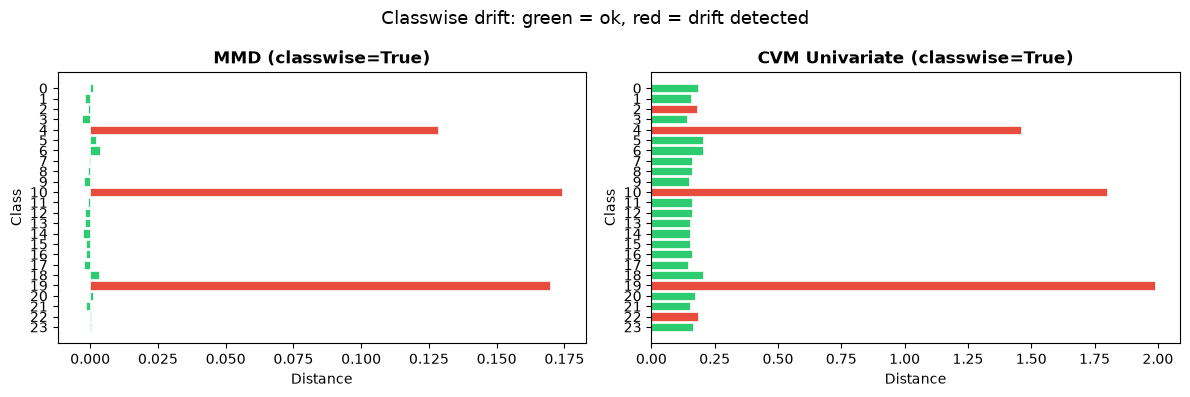

In [13]:
assert raw.classwise is not None  # classwise=True was set on each detector above
detectors = [cw["detector"] for cw in raw.classwise]

fig, axes = plt.subplots(1, len(detectors), figsize=(6 * len(detectors), 4))
if len(detectors) == 1:
    axes = [axes]

for ax, cw in zip(axes, raw.classwise, strict=True):
    class_names = [r["class_name"] for r in cw["rows"]]
    distances = [r["distance"] for r in cw["rows"]]
    drifted = [r["drifted"] for r in cw["rows"]]
    colors = ["#e74c3c" if d else "#2ecc71" for d in drifted]

    ax.barh(class_names, distances, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Class")
    ax.set_title(cw["detector"], fontsize=12, fontweight="bold")
    ax.invert_yaxis()

fig.suptitle("Classwise drift: green = ok, red = drift detected", fontsize=13)
plt.tight_layout()
plt.show()